In [2]:
# Import libraries
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(
    r'C:\Users\Admin\Desktop\BIA Capstone Project\data\processed\EDA.csv'
)

In [5]:
# Convert datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Revenue      392692 non-null  float64       
 9   Month        392692 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(2), object(3), period[M](1)
memory usage: 30.0+ MB


In [7]:
# Created a column for the snapshot date which tells us the date of the last invoice in the dataset. We will use this to calculate recency.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [8]:
# Calculating RFM metrics for each customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})
rfm

,InvoiceDate,InvoiceNo,Revenue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [9]:
# Created RFM columnsand renamed them to Recency, Frequency, and Monetary
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


RFM
Recency: Number of days since last purchase.
Lower value = better
Frequency: Number of unique purchase
Higher value = better
Monetary: Total value spent
Higher value = better

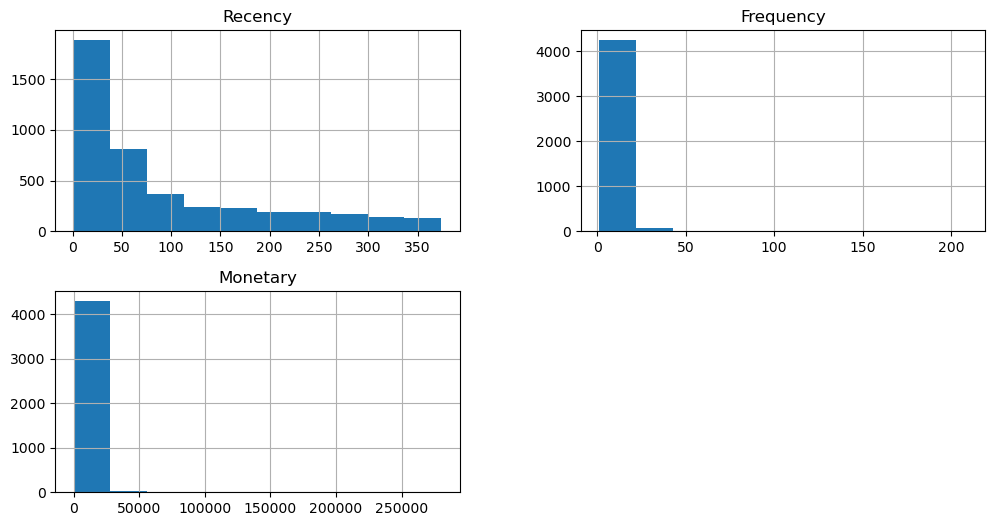

In [11]:
# This shows the distribution of the RFM metrics. We can see that the data is skewed, which is common in RFM analysis. We will need to transform the data before clustering.
import matplotlib.pyplot as plt
import seaborn as sns

rfm.hist(figsize=(12, 6))
plt.show()

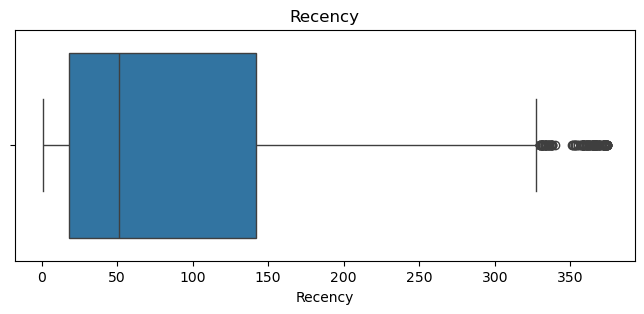

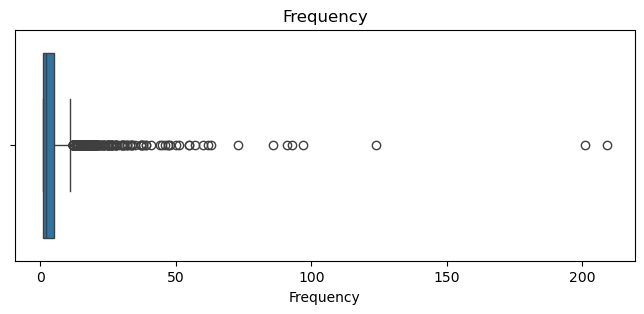

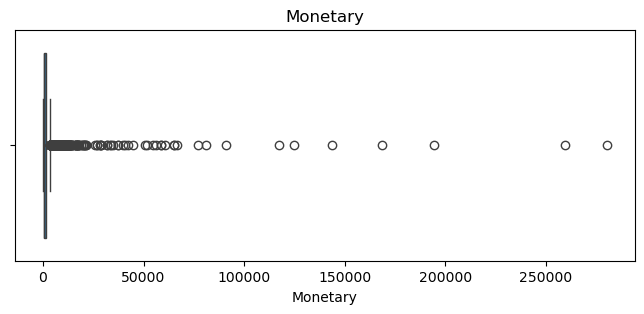

In [12]:
# Distribution of RFM using boxplots.
for col in rfm.columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=rfm[col])
    plt.title(col)
    plt.show()

In [13]:
# Skewness of RFM.
rfm.skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

Frequncy and Monetary are highly skewed.

In [14]:
# Using log transformation to reduce skewness.
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [15]:
# Transformed RFM using log transformation.
rfm_log.skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64

The RFM features exhibited significant positive skewness, particularly Frequency (12.07) and Monetary (19.34). Since clustering algorithms such as K-Means are sensitive to highly skewed distributions, a log transformation (log1p) was applied. After transformation, the skewness reduced substantially, resulting in a more balanced distribution suitable for clustering.

In [16]:
# Standard Scaling
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

rfm_scaled = scalar.fit_transform(rfm_log)

In [17]:
# Create a new dataframe with scaled values after log transformation. This will be used for clustering.
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.707716
12347.0,-2.038734,1.074425,1.414903
12348.0,0.373104,0.386304,0.720024
12349.0,-0.623086,-0.955214,0.702287
12350.0,1.424558,-0.955214,-0.614514


In [18]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,-3.669008e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-3.997811e+00
25%,-6.613615e-01,-9.552143e-01,-6.835802e-01
50%,8.992557e-02,-3.615828e-01,-6.510929e-02
75%,8.447915e-01,6.532370e-01,6.572178e-01
max,1.564198e+00,5.858535e+00,4.732381e+00


In [19]:
# Import K Means
from sklearn.cluster import KMeans

sum_of_sqr = []

# K-Means cannot determine the exact number of K values. It does as we say so for that we use Elbow method.

In [20]:
# Using Elbow method to find the number of clusters required.
for k in range(1, 11):
    kmeans = KMeans (
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )
    kmeans.fit(rfm_scaled)
    sum_of_sqr.append(kmeans.inertia_)
sum_of_sqr

[13013.999999999998,
 6483.589425039294,
 4869.488628540215,
 3939.04938163916,
 3296.708707642544,
 2855.764068043109,
 2548.8202448495617,
 2336.3410536103925,
 2156.0056725213444,
 2005.746236269557]

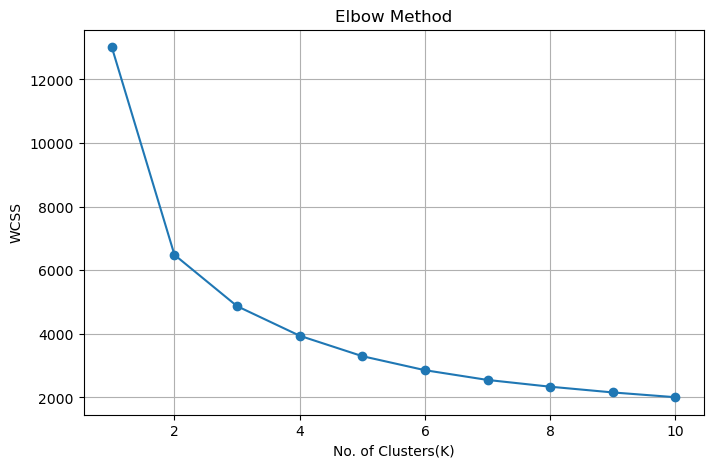

In [21]:
# Plotting the Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    sum_of_sqr,
    marker = 'o'
)

plt.title('Elbow Method')
plt.xlabel('No. of Clusters(K)')
plt.ylabel('WCSS')  #Within-Cluster Sum of squares

plt.grid(True)

plt.show()

OBSERVATION: Elbow Method is used to detrmine optimal number of customer clusters.
The WCSS decreased rapidly from K=1 to K=4. Later on, as the K value is increased the rate of improvement is slowed significantly. This indicates that after 4 there will be marginal gains.

In [22]:
# Silhoutte Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

In [23]:
# Using Silhouette Score to find the number of clusters required.
for k in range(2, 11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score=silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

In [24]:
# Finding K value usin Silhouette score.
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: score = {score:.4f}")

silhouette_score

K = 2: score = 0.4328
K = 3: score = 0.3365
K = 4: score = 0.3375
K = 5: score = 0.3162
K = 6: score = 0.3124
K = 7: score = 0.3092
K = 8: score = 0.3033
K = 9: score = 0.2811
K = 10: score = 0.2767


<function sklearn.metrics.cluster._unsupervised.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)>

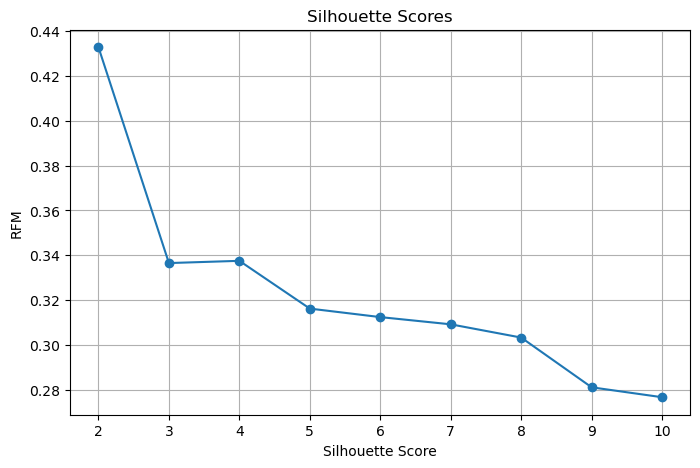

In [25]:
# Plotting Silhouette Scores
plt.figure(figsize=(8, 5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Scores')
plt.xlabel('Silhouette Score')
plt.ylabel('RFM')

plt.grid(True)

plt.show()

OBSERVATION: 
Silhouette Score: Based on my analysis silhouette score should be 5 because after 5 there are very slight changes except one big change from 8 to 9. 8 is 0.3033 and 9 is 0.2811. But it shouldn't taken into consideration because Elbow method is also 4. This indicates after 4 and 5 rate of improvement is very minimum. 

The Elbow Method suggested K = 4 as the point after which the reduction in WCSS became marginal. The Silhouette Score was highest for K = 2 as 0.4328 indicating strongest statistical seperation between two clusters. For business purpose K = 4 is identical because it provides more meaningful and actionable customer segments.

In [26]:
# Train the model KMeans(Unsupervised Learning)

kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

In [27]:
rfm['Cluster'] = clusters

In [28]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

In [29]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


In [30]:
type(rfm)

pandas.core.frame.DataFrame

In [31]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


In [32]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'Cluster'], dtype='object')

In [33]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

In [34]:
# This shows the average Recency, Frequency, and Monetary values for each cluster. We can use this information to understand the characteristics of each cluster and make business decisions accordingly.
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,12.171108,13.751753,8088.018331
1,181.506782,1.316893,340.998626
2,17.698925,2.192354,557.322616
3,71.635506,4.078902,1801.777893


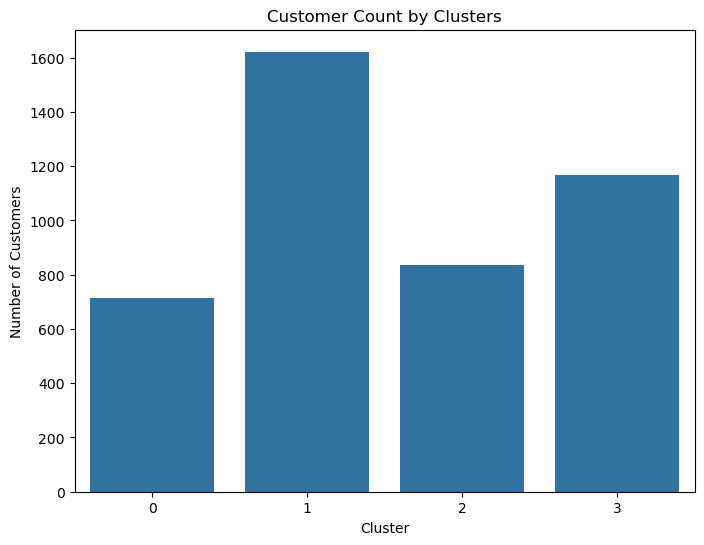

In [35]:
# Visualizing the clusters using a countplot to see the number of customers in each cluster.
plt.figure(figsize=(8,6))

sns.countplot(
    x='Cluster',
    data=rfm
)

plt.title('Customer Count by Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.show()

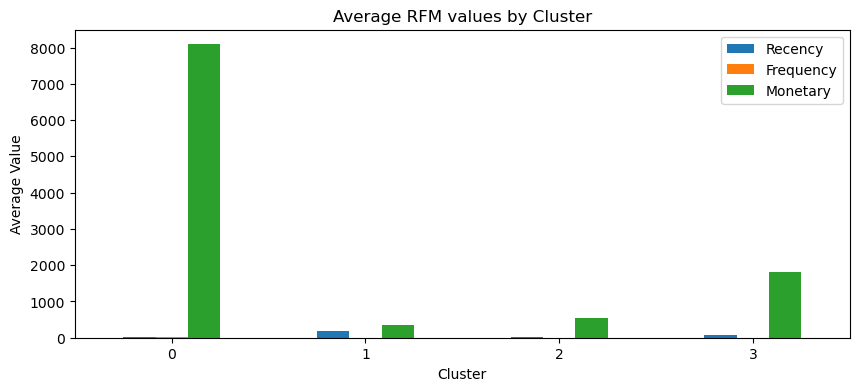

In [36]:
# Visualizing the clusters using a bar plot to see the average RFM values for each cluster.
cluster_summary.plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Average RFM values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')

plt.xticks(rotation=0)

plt.show()

Observation: Since Monetary values are much larger than recency and Frequency, the Monetary bars dominate the graph. This is expected because all three metrics are measured on different scale.

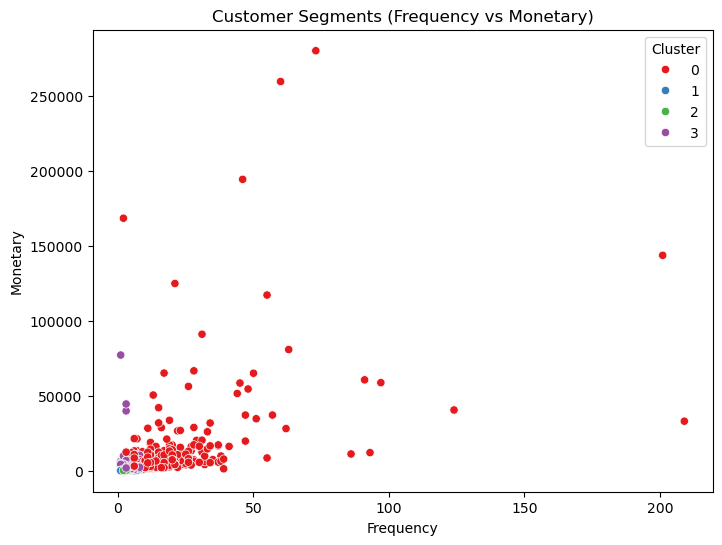

In [37]:
# Visualizing the clusters using a scatter plot to see the relationship between Frequency and Monetary values for each cluster.
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments (Frequency vs Monetary)')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

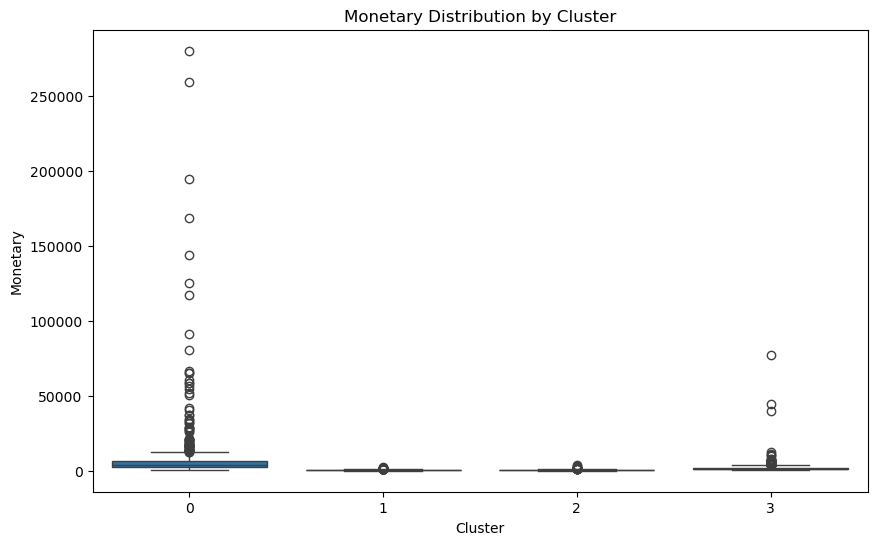

In [38]:
# Visualizing the clusters using a boxplot to see the distribution of Monetary values for each cluster.
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Monetary',
    data=rfm
)

plt.title('Monetary Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Monetary')

plt.show()

The boxplot shows that Cluster 0 contains several high-value outliers. These customers spend significantly more than the average customer, indicating the presence of premium customers. Since these values represent genuine purchasing behavior rather than data errors, they were retained in the analysis.

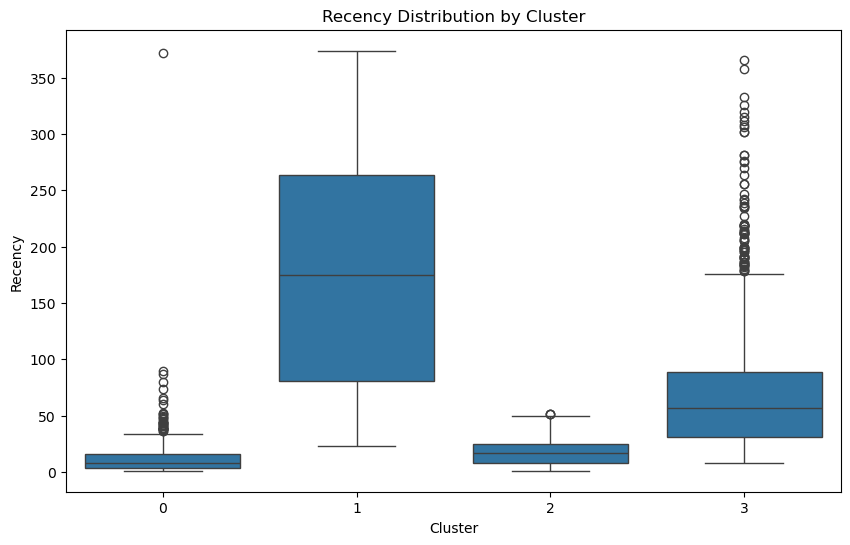

In [39]:
# Visualizing the clusters using a boxplot to see the distribution of Recency values for each cluster.
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Recency',
    data=rfm
)

plt.title('Recency Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Recency')

plt.show()

Cluster 0 contains customers with exceptionally high purchase frequency, indicating very loyal and active customers.

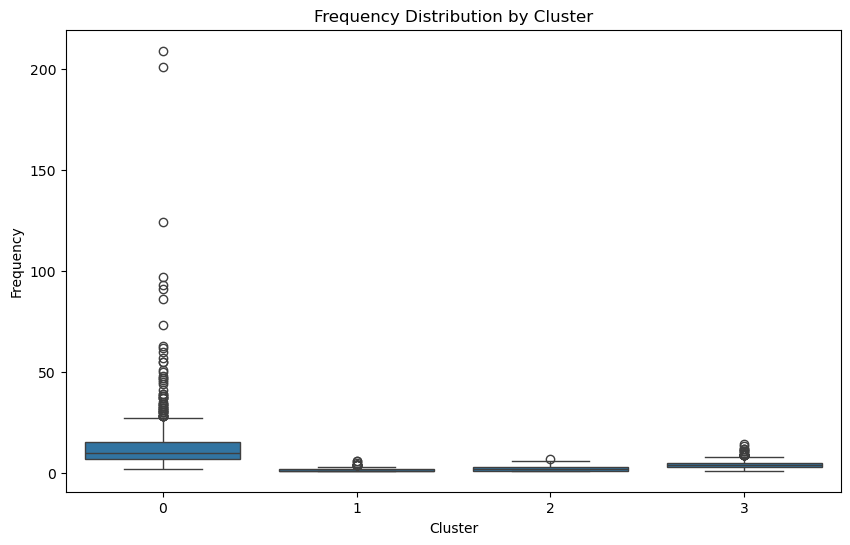

In [40]:
# Visualizing the clusters using a boxplot to see the distribution of Frequency values for each cluster.
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Frequency',
    data=rfm
)

plt.title('Frequency Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')

plt.show()

Cluster 1 has the highest Recency values, showing customers who have not purchased for a long period. Cluster 0 has the lowest Recency values, indicating recent purchases and active engagement.

In [41]:
import os
import joblib

In [42]:
# Save the K-Means Model and Scalar Model
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scalar, 'scalar.pkl')

['scalar.pkl']

In [43]:
# HIERARCHICAL CLUSTER

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

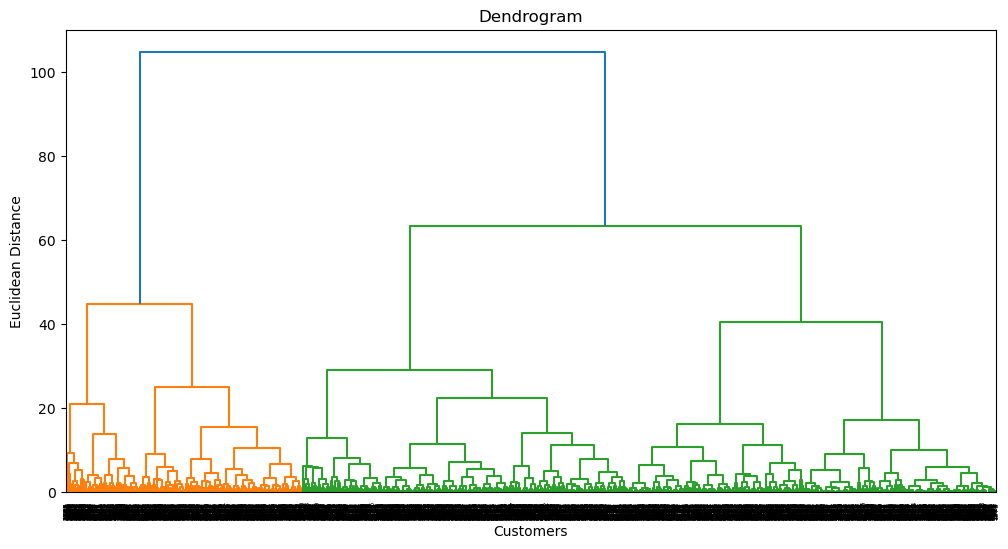

In [44]:
# Plotting the Dendrogram to visualize the hierarchical clustering of customers based on their RFM values. The dendrogram shows the hierarchical relationship between customers and helps us determine the optimal number of clusters.

linked = linkage(
    rfm_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

plt.show()

In [45]:
# Train the model using Agglomerative Clustering. This shows how we can use hierarchical clustering to segment customers based on their RFM values. We can use the dendrogram to determine the optimal number of clusters and then use Agglomerative Clustering to assign each customer to a cluster.

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

rfm['HC_Cluster'] = hc.fit_predict(rfm_scaled)


In [46]:
rfm['HC_Cluster'].value_counts()

HC_Cluster
0    1716
2    1517
1     762
3     343
Name: count, dtype: int64

In [47]:
# Check cluster distribution
rfm.groupby('HC_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
HC_Cluster,,,
0,146.576923,1.262821,270.308351
1,9.685039,5.460630,1811.131142
2,91.006592,3.460119,1558.658572
3,13.002915,20.276968,13640.795277


Text(0, 0.5, 'Count of Customers')

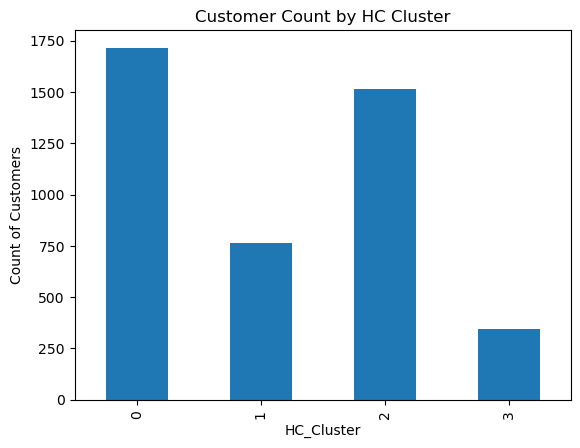

In [48]:
# Visualisation of Hierarchical clustering using a bar plot to see the average RFM values for each cluster.
rfm['HC_Cluster'].value_counts().sort_index().plot(kind='bar')

plt.title('Customer Count by HC Cluster')
plt.ylabel('Count of Customers')

Text(0, 0.5, 'Average RFM Values')

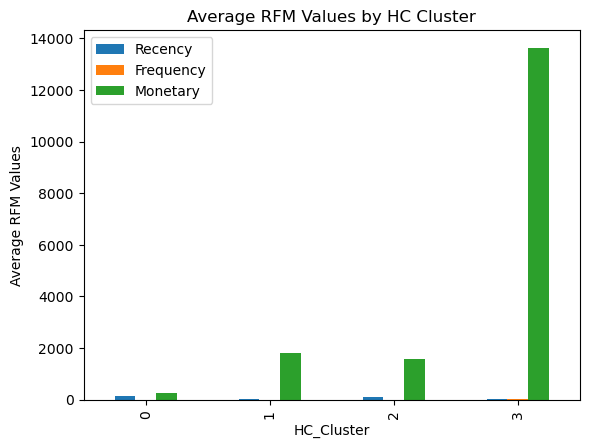

In [49]:
# Visualisation of Hierarchical clustering using a bar plot to see the average RFM values for each cluster.
rfm.groupby('HC_Cluster')[['Recency','Frequency','Monetary']].mean().plot(kind='bar')

plt.title('Average RFM Values by HC Cluster')
plt.ylabel('Average RFM Values')

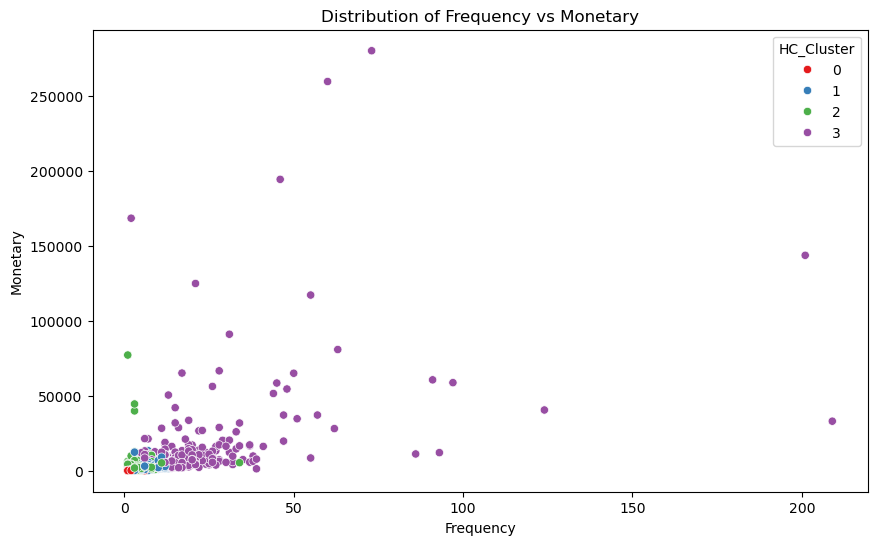

In [50]:
# Visalising the clusters using scatter plot to see the relationship between Frequency & Monetary values.
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='HC_Cluster',
    palette='Set1'
)

plt.title('Distribution of Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

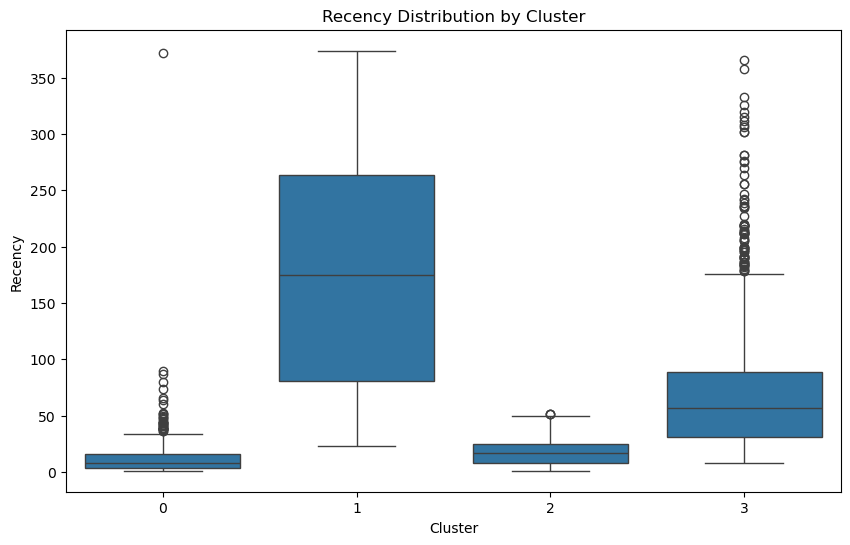

In [51]:
# Visualizing the clusters using a boxplot to see the distribution of Recency values for each cluster.
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Recency',
    data=rfm
)

plt.title('Recency Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Recency')

plt.show()

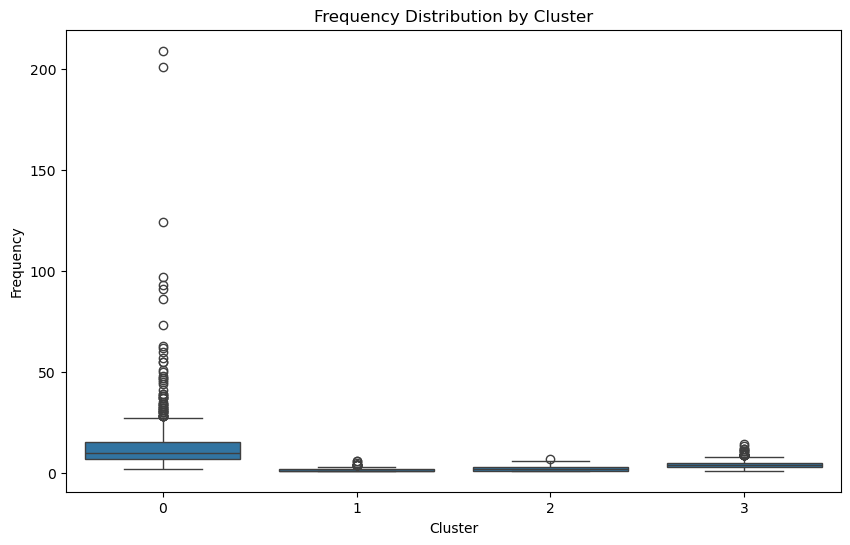

In [52]:
# Visualizing the clusters using a boxplot to see the distribution of Frequency values for each cluster.
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Frequency',
    data=rfm
)

plt.title('Frequency Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')

plt.show()

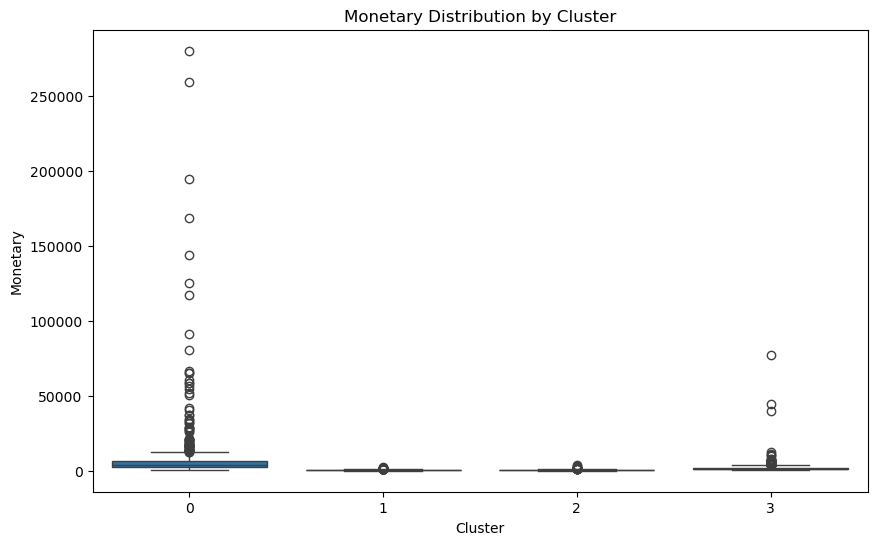

In [53]:
# Visualizing the clusters using a boxplot to see the distribution of Monetary values for each cluster.
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Monetary',
    data=rfm
)

plt.title('Monetary Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Monetary')

plt.show()

In [54]:
# Nearest Neighbors
from sklearn.neighbors import NearestNeighbors

In [55]:
# Finding the optimal number of neighbors for the Nearest Neighbors algorithm. This shows how we can use the Nearest Neighbors algorithm to find similar customers based on their RFM values. We can use this information to make business decisions such as targeted marketing campaigns or personalized recommendations.
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(rfm_scaled)

distances, indices = neighbors_fit.kneighbors(rfm_scaled)

distances = np.sort(distances[:, 4])

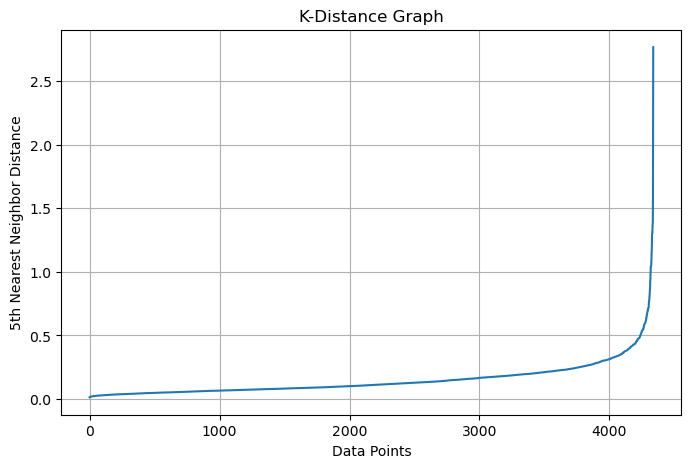

In [56]:
# This shows the K-Distance graph which helps us determine the optimal value of epsilon for the DBSCAN algorithm. The K-Distance graph plots the distance to the 5th nearest neighbor for each data point. We can use this information to find the optimal value of epsilon for DBSCAN clustering.
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

In [57]:
# train the DBSCAN model
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.4,
    min_samples=5
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

In [58]:
# The values shows the number of customers in each cluster. We can see that there are some customers that are considered as noise (cluster -1) and some customers that are assigned to clusters 0, 1, and 2. We can use this information to make business decisions such as targeted marketing campaigns or personalized recommendations.
rfm['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    1925
 1    1473
 2     828
-1     100
 5       5
 3       4
 4       3
Name: count, dtype: int64

In [65]:
from sklearn.decomposition import PCA

# Reduce the 3 RFM dimensions to 2 dimensions for visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

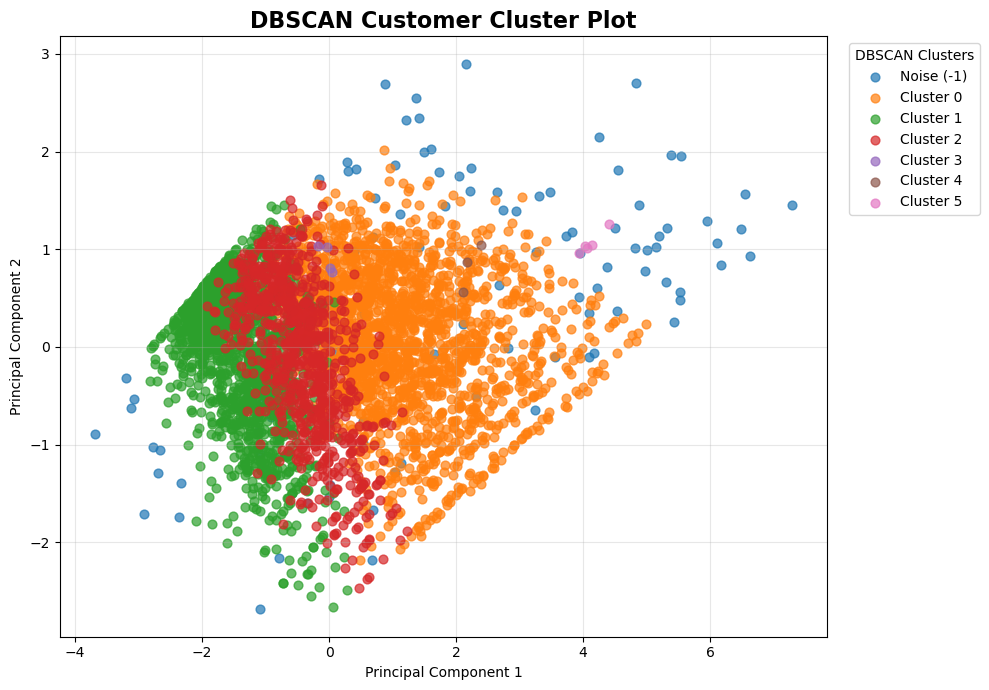

In [68]:
# Create DBSCAN cluster plot
plt.figure(figsize=(10, 7))

unique_clusters = sorted(rfm['DBSCAN_Cluster'].unique())

for cluster in unique_clusters:
    
    mask = rfm['DBSCAN_Cluster'] == cluster
    
    # Give noise points a clear label
    if cluster == -1:
        label = 'Noise (-1)'
    else:
        label = f'Cluster {cluster}'
    
    plt.scatter(
        rfm_pca[mask, 0],
        rfm_pca[mask, 1],
        s=40,
        alpha=0.7,
        label=label
    )
plt.title(
    'DBSCAN Customer Cluster Plot',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
    title='DBSCAN Clusters',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# This shows the average Recency, Frequency, and Monetary values for each cluster. We can use this information to understand the characteristics of each cluster and make business decisions accordingly.
rfm.groupby('DBSCAN_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
comparison = pd.DataFrame({
    'Metric': [
        'No. of Clusters',
        'Requires K',
        'Detects Outliers',
        'Scalability',
        'Interpretability',
        'Best Use Case',
        'Result in Project'
    ],
    'K-Means': [
        4,
        'Yes',
        'No',
        'High',
        'High',
        'Customer Segmentation',
        'Selected as Best Model'
    ],
    'Hierarchical': [
        4,
        'Yes',
        'No',
        'Medium',
        'High',
        'Hierarchy Analysis',
        'Good Alternative'
    ],
    'DBSCAN': [
        '6 + Noise',
        'No',
        'Yes',
        'Medium',
        'Medium',
        'Outlier Detection',
        'Not Preferred'
    ]
})

comparison

,Metric,K-Means,Hierarchical,DBSCAN
0,No. of Clusters,4,4,6 + Noise
1,Requires K,Yes,Yes,No
2,Detects Outliers,No,No,Yes
3,Scalability,High,Medium,Medium
4,Interpretability,High,High,Medium
5,Best Use Case,Customer Segmentation,Hierarchy Analysis,Outlier Detection
6,Result in Project,Selected as Best Model,Good Alternative,Not Preferred


In [59]:
# Segment Mapping
segment_map = {
    0: 'VIP',
    1: 'At Risk',
    2: 'New',
    3: 'Loyal'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

In [60]:
# Check
rfm[['Cluster', 'Segment']].head()

,Cluster,Segment
CustomerID,,
12346.0,3,Loyal
12347.0,0,VIP
12348.0,3,Loyal
12349.0,2,New
12350.0,1,At Risk


In [61]:
# Create Target Variable
rfm['High_Value_Customer']=rfm['Segment'].apply(
    lambda x: 1 if x in ['VIP', 'Loyal'] else 0
)

In [62]:
# Check the distribution
rfm['High_Value_Customer'].value_counts()

High_Value_Customer
0    2459
1    1879
Name: count, dtype: int64

In [63]:
rfm['High_Value_Customer'].value_counts(normalize=True) * 100

High_Value_Customer
0    56.685108
1    43.314892
Name: proportion, dtype: float64

In [64]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['High_Value_Customer']